In [2]:
import json
import random
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

BASE = Path('/home/zzou')

def show_images(images, titles):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, img_path, title in zip(axes, images, titles):
        ax.imshow(mpimg.imread(str(BASE / img_path)))
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## Test 01 — Aligned First (image pairs)

In [3]:
data01 = json.load(open(BASE / 'comfort_eval_tests/test01_aligned_first/image_pairs.json'))
example01 = random.choice(data01)
print(f'Total examples: {len(data01)}')
print('Sampled example:')
for k, v in example01.items():
    print(f'  {k}: {v}')

Total examples: 108
Sampled example:
  img1: COMFORT/data/comfort_human_car/totheleft/car__totheleft__cam_back/0.png
  img2: COMFORT/data/comfort_human_car/totheleft/car__totheleft__cam_right/0.png
  cam_view_1: cam_back
  cam_view_2: cam_right


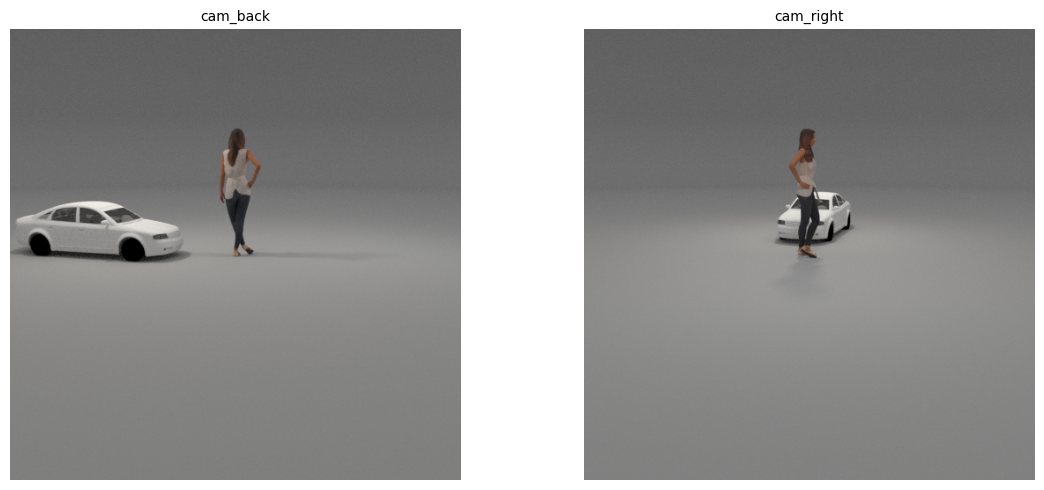

In [4]:
show_images(
    [example01['img1'], example01['img2']],
    [example01['cam_view_1'], example01['cam_view_2']]
)

## Test 02 — POV (image triples)

In [5]:
data02 = json.load(open(BASE / 'comfort_eval_tests/test02_pov/image_triples.json'))
example02 = random.choice(data02)
print(f'Total examples: {len(data02)}')
print('Sampled example:')
for k, v in example02.items():
    print(f'  {k}: {v}')

Total examples: 144
Sampled example:
  external_img: COMFORT/data/comfort_human_car_pov/behind/dog__behind__cam_front/0.png
  correct_pov_img: COMFORT/data/comfort_human_car_pov/behind/dog__behind__cam_pov_front/0.png
  distractor_pov_img: COMFORT/data/comfort_human_car_pov/behind/dog__behind__cam_pov_back/0.png
  cam_view_external: cam_front
  cam_view_correct: cam_pov_front
  cam_view_distractor: cam_pov_back
  second_object: dog
  correct_relation: behind


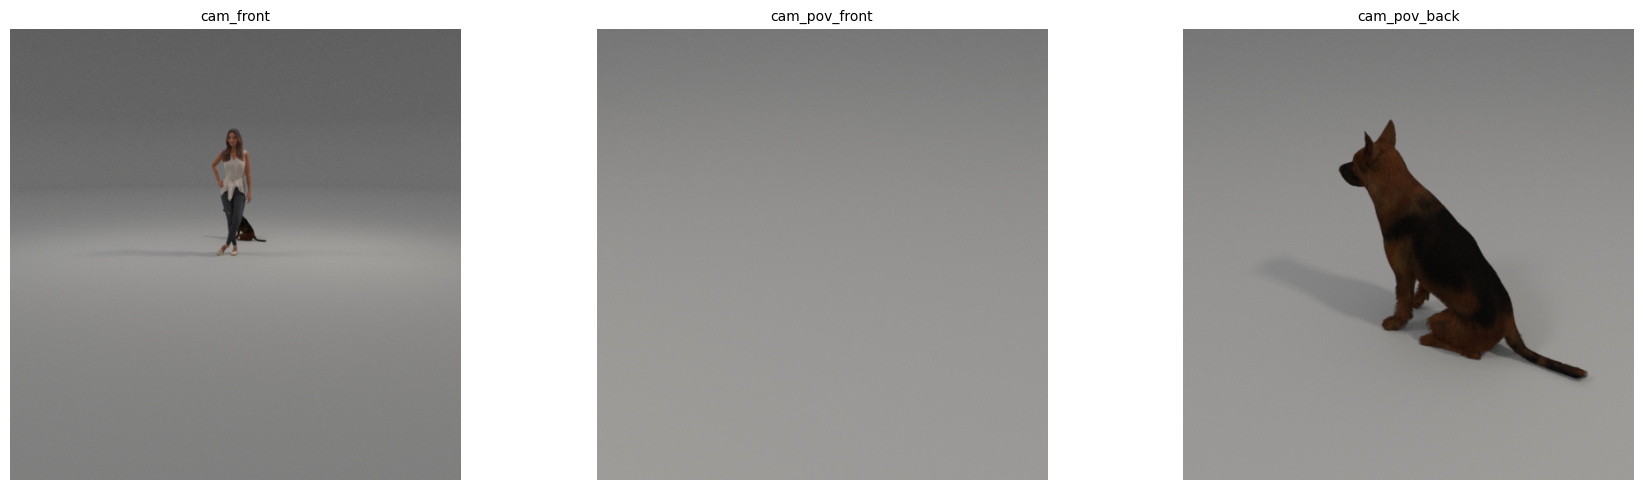

In [6]:
show_images(
    [example02['external_img'], example02['correct_pov_img'], example02['distractor_pov_img']],
    [example02['cam_view_external'], example02['cam_view_correct'], example02['cam_view_distractor']]
)

## Test 03 — POV Four (image quads)

In [7]:
data03 = json.load(open(BASE / 'comfort_eval_tests/test03_pov_four/image_quads.json'))
example03 = random.choice(data03)
print(f'Total examples: {len(data03)}')
print('Sampled example:')
for k, v in example03.items():
    print(f'  {k}: {v}')

Total examples: 432
Sampled example:
  external_img: COMFORT/data/comfort_human_car_pov_two/infrontof/car__infrontof__cam_front__third_duck_at_totheright/0.png
  pov_correct: COMFORT/data/comfort_human_car_pov_two/infrontof/car__infrontof__cam_pov_front__third_duck_at_totheright/0.png
  pov_dist1: COMFORT/data/comfort_human_car_pov_two/infrontof/car__infrontof__cam_pov_right__third_duck_at_totheright/0.png
  pov_dist2: COMFORT/data/comfort_human_car_pov_two/infrontof/car__infrontof__cam_pov_back__third_duck_at_totheright/0.png
  cam_correct: cam_pov_front
  cam_dist1: cam_pov_right
  cam_dist2: cam_pov_back
  cam_view_external: cam_front
  second_object: car
  correct_relation: front
  third_object: duck
  third_object_relation: right


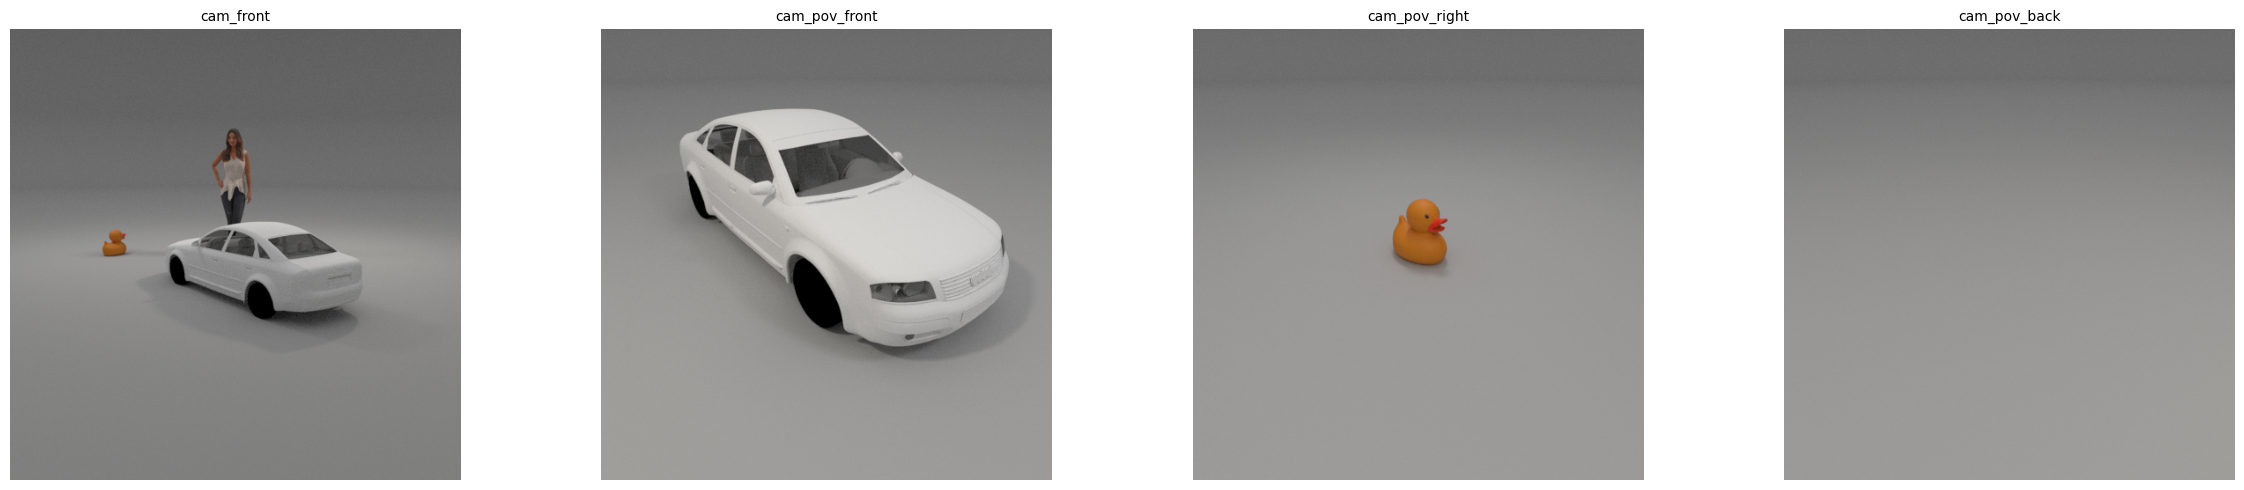

In [8]:
show_images(
    [example03['external_img'], example03['pov_correct'], example03['pov_dist1'], example03['pov_dist2']],
    [example03['cam_view_external'], example03['cam_correct'], example03['cam_dist1'], example03['cam_dist2']]
)

## Dataset visualizations for report

The cells below use fixed examples from each subset so the figures are stable across runs.


In [9]:
DATA_ROOT = BASE / 'COMFORT/data'
CAMERA_ORDER = ['cam_front', 'cam_back', 'cam_left', 'cam_right']
RELATION_LABEL = {
    'infrontof': 'front',
    'behind': 'behind',
    'totheleft': 'left',
    'totheright': 'right',
}


def image_path(dataset, relation, obj, view, third_object=None, third_relation=None):
    folder = f'{obj}__{relation}__{view}'
    if third_object is not None:
        folder += f'__third_{third_object}_at_{third_relation}'
    return DATA_ROOT / dataset / relation / folder / '0.png'


def show_report_grid(items, ncols, figsize=(14, 8), suptitle=None):
    nrows = (len(items) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    for ax in axes.ravel():
        ax.axis('off')
    for ax, item in zip(axes.ravel(), items):
        path = item['path']
        ax.imshow(mpimg.imread(str(path)))
        ax.set_title(item['title'], fontsize=11, pad=8)
        ax.axis('off')
    if suptitle:
        fig.suptitle(suptitle, fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()


def external_view_items(dataset, relation, obj):
    answer = RELATION_LABEL[relation]
    return [
        {
            'path': image_path(dataset, relation, obj, view),
            'title': f'{view.replace("cam_", "camera: ")}\nGT object position: {answer}',
        }
        for view in CAMERA_ORDER
    ]


def choose_record(records, **criteria):
    for record in records:
        if all(record.get(k) == v for k, v in criteria.items()):
            return record
    raise ValueError(f'No record found for {criteria}')


### Single-object scenes: `comfort_human_car`

One human and one target object are rendered from four external camera viewpoints. The ground-truth relation stays fixed while the observer viewpoint changes.


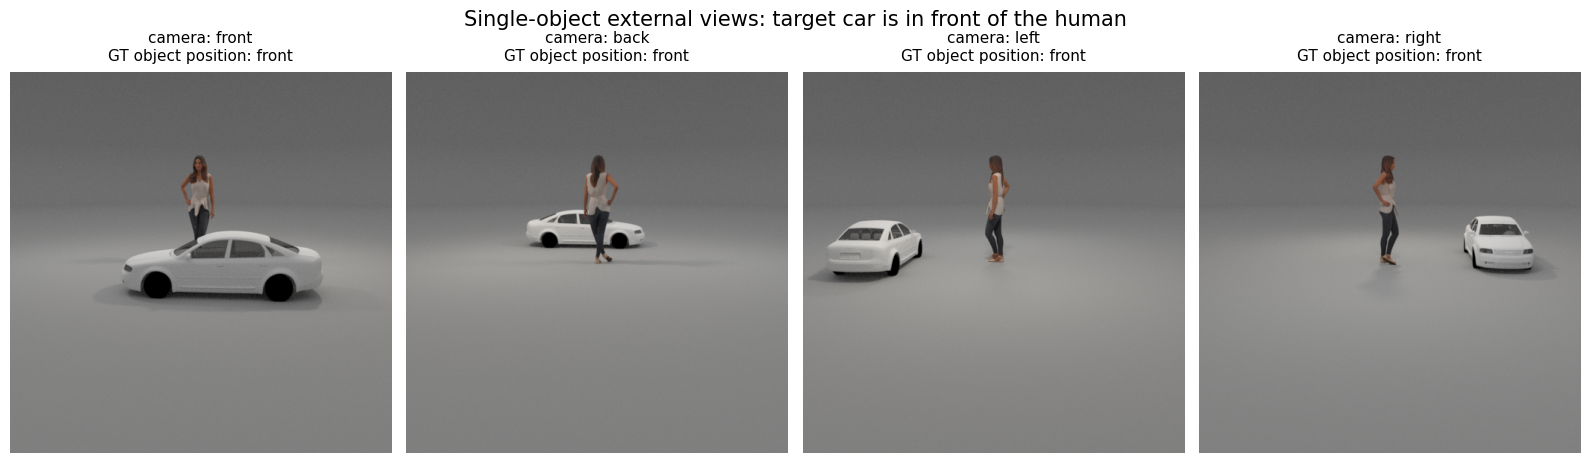

In [10]:
show_report_grid(
    external_view_items('comfort_human_car', relation='infrontof', obj='car'),
    ncols=4,
    figsize=(16, 4.5),
    suptitle='Single-object external views: target car is in front of the human',
)


### Visual marker scenes: `comfort_human_car_visual_marks`

This subset mirrors the single-object scenes and adds a red arrow that explicitly marks the human's facing direction.


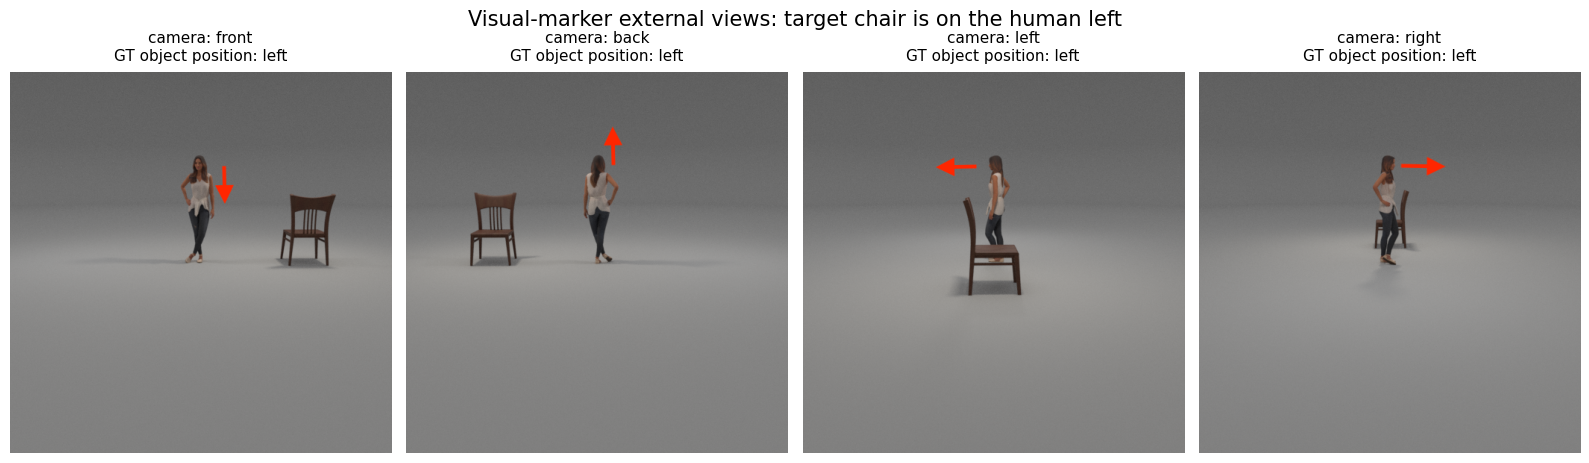

In [11]:
show_report_grid(
    external_view_items('comfort_human_car_visual_marks', relation='totheleft', obj='chair'),
    ncols=4,
    figsize=(16, 4.5),
    suptitle='Visual-marker external views: target chair is on the human left',
)


### POV scenes: `comfort_human_car_pov`

The model receives one external view and chooses the correct forward-facing first-person view from two options.


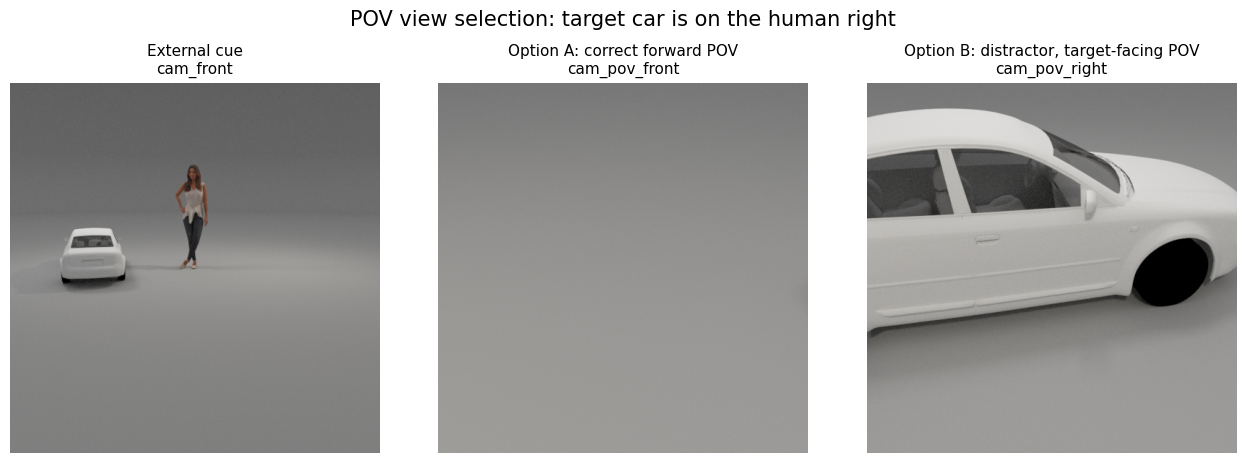

In [12]:
data02 = json.load(open(BASE / 'comfort_eval_tests/test02_pov/image_triples.json'))
pov_example = choose_record(data02, second_object='car', correct_relation='right', cam_view_external='cam_front')
show_report_grid(
    [
        {'path': BASE / pov_example['external_img'], 'title': f"External cue\n{pov_example['cam_view_external']}"},
        {'path': BASE / pov_example['correct_pov_img'], 'title': f"Option A: correct forward POV\n{pov_example['cam_view_correct']}"},
        {'path': BASE / pov_example['distractor_pov_img'], 'title': f"Option B: distractor, target-facing POV\n{pov_example['cam_view_distractor']}"},
    ],
    ncols=3,
    figsize=(13, 4.5),
    suptitle='POV view selection: target car is on the human right',
)


### Two-object POV scenes: `comfort_human_car_pov_two`

A non-target object is added at another cardinal position. The answer is still determined by the queried target object, not by the distractor object.


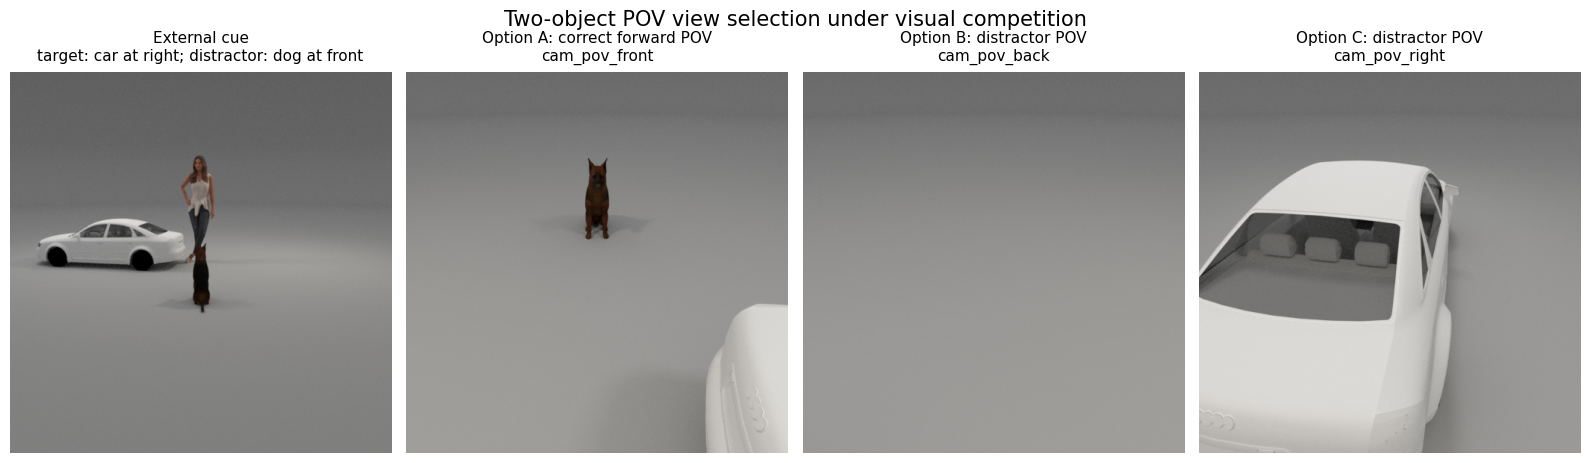

In [13]:
data03 = json.load(open(BASE / 'comfort_eval_tests/test03_pov_four/image_quads.json'))
pov_two_example = choose_record(
    data03,
    second_object='car',
    correct_relation='right',
    third_object='dog',
    third_object_relation='front',
    cam_view_external='cam_front',
)
show_report_grid(
    [
        {'path': BASE / pov_two_example['external_img'], 'title': f"External cue\ntarget: {pov_two_example['second_object']} at right; distractor: {pov_two_example['third_object']} at front"},
        {'path': BASE / pov_two_example['pov_correct'], 'title': f"Option A: correct forward POV\n{pov_two_example['cam_correct']}"},
        {'path': BASE / pov_two_example['pov_dist1'], 'title': f"Option B: distractor POV\n{pov_two_example['cam_dist1']}"},
        {'path': BASE / pov_two_example['pov_dist2'], 'title': f"Option C: distractor POV\n{pov_two_example['cam_dist2']}"},
    ],
    ncols=4,
    figsize=(16, 4.5),
    suptitle='Two-object POV view selection under visual competition',
)


## Evaluation test examples for report

This section creates one overview figure showing the image inputs and prompt used by each evaluation test.


Saved figure to /home/zzou/comfort_eval_tests/test_overview_examples.png


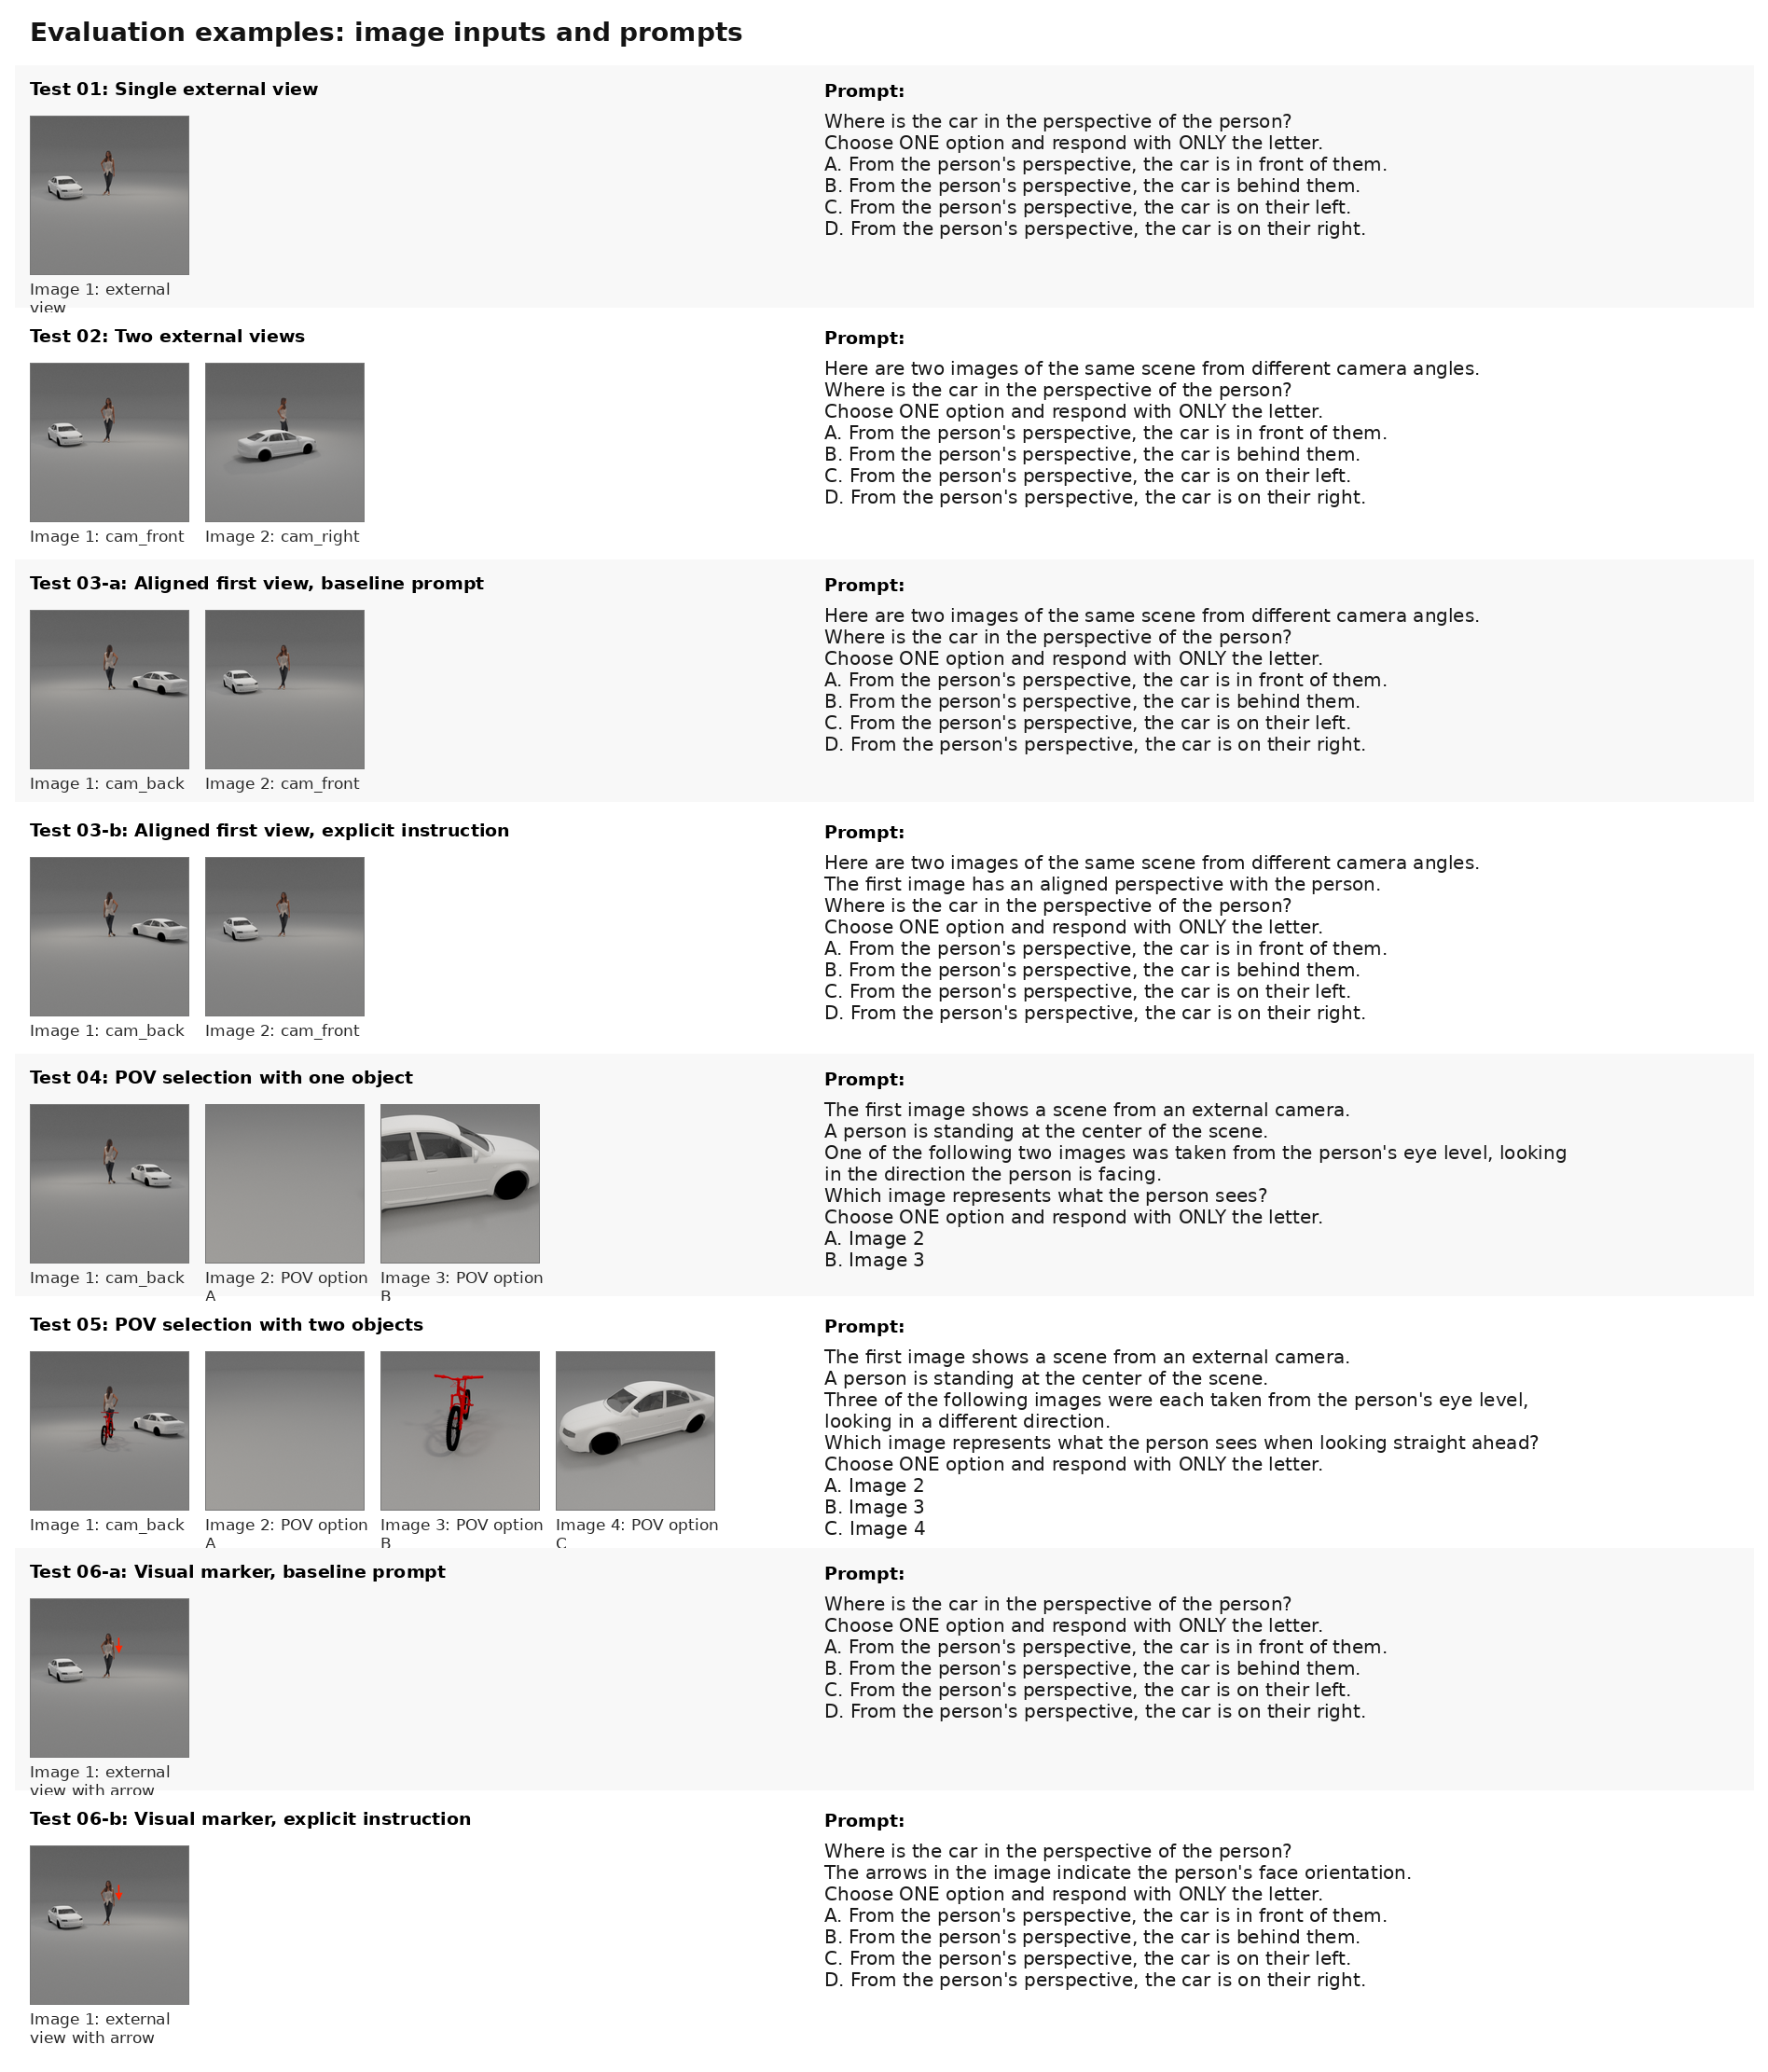

In [15]:
from PIL import Image, ImageDraw, ImageFont
import textwrap

OUT_FIG = BASE / 'comfort_eval_tests/test_overview_examples.png'

RELATION_LABELS = {
    'infrontof': 'front',
    'totheleft': 'left',
    'totheright': 'right',
    'behind': 'behind',
}

LONG_RELATIONS = {
    'front': 'From the person\'s perspective, the {second_object} is in front of them.',
    'behind': 'From the person\'s perspective, the {second_object} is behind them.',
    'left': 'From the person\'s perspective, the {second_object} is on their left.',
    'right': 'From the person\'s perspective, the {second_object} is on their right.',
}


def parse_scene(path):
    p = Path(path)
    relation_dir = p.parts[-3]
    scene = p.parts[-2]
    parts = scene.split('__')
    obj = parts[0]
    relation = RELATION_LABELS.get(relation_dir, relation_dir)
    return obj, relation


def single_mcq_prompt(obj, prompt_note=''):
    options = {
        'A': LONG_RELATIONS['front'].format(second_object=obj),
        'B': LONG_RELATIONS['behind'].format(second_object=obj),
        'C': LONG_RELATIONS['left'].format(second_object=obj),
        'D': LONG_RELATIONS['right'].format(second_object=obj),
    }
    lines = [f'Where is the {obj} in the perspective of the person?']
    if prompt_note:
        lines.append(prompt_note)
    lines.extend(['Choose ONE option and respond with ONLY the letter.'])
    lines.extend([f'{k}. {v}' for k, v in options.items()])
    return '\n'.join(lines)


def pair_mcq_prompt(obj, aligned_note=False):
    lines = ['Here are two images of the same scene from different camera angles.']
    if aligned_note:
        lines.append('The first image has an aligned perspective with the person.')
    lines.append(f'Where is the {obj} in the perspective of the person?')
    lines.append('Choose ONE option and respond with ONLY the letter.')
    for k, rel in zip(['A', 'B', 'C', 'D'], ['front', 'behind', 'left', 'right']):
        lines.append(f'{k}. {LONG_RELATIONS[rel].format(second_object=obj)}')
    return '\n'.join(lines)


def pov_prompt():
    return (
        'The first image shows a scene from an external camera.\n'
        'A person is standing at the center of the scene.\n'
        'One of the following two images was taken from the person\'s eye level, '
        'looking in the direction the person is facing.\n'
        'Which image represents what the person sees?\n'
        'Choose ONE option and respond with ONLY the letter.\n'
        'A. Image 2\n'
        'B. Image 3'
    )


def pov4_prompt():
    return (
        'The first image shows a scene from an external camera.\n'
        'A person is standing at the center of the scene.\n'
        'Three of the following images were each taken from the person\'s eye level, '
        'looking in a different direction.\n'
        'Which image represents what the person sees when looking straight ahead?\n'
        'Choose ONE option and respond with ONLY the letter.\n'
        'A. Image 2\n'
        'B. Image 3\n'
        'C. Image 4'
    )


def load_json(rel_path):
    return json.load(open(BASE / rel_path, encoding='utf-8'))


def choose_path(paths, contains):
    for path in paths:
        if contains in path:
            return path
    return paths[0]


single_paths = load_json('comfort_image_paths.json')
visual_paths = load_json('comfort_eval_tests/test04_visual_marks/image_paths.json')
pair_paths = load_json('comfort_image_pairs.json')
aligned_pairs = load_json('comfort_eval_tests/test01_aligned_first/image_pairs.json')
triples = load_json('comfort_eval_tests/test02_pov/image_triples.json')
quads = load_json('comfort_eval_tests/test03_pov_four/image_quads.json')

single_img = choose_path(single_paths, 'car__totheright__cam_front')
obj_single, _ = parse_scene(single_img)

pair = next(x for x in pair_paths if 'car__totheright' in x['img1'] and 'cam_front' in x['cam_view_1'] and 'cam_right' in x['cam_view_2'])
aligned_pair = next(x for x in aligned_pairs if 'car__totheright' in x['img1'])
triple = next(x for x in triples if x['second_object'] == 'car' and x['correct_relation'] == 'right')
quad = next(x for x in quads if x['second_object'] == 'car' and x['correct_relation'] == 'right')
visual_img = choose_path(visual_paths, 'car__totheright__cam_front')

rows = [
    {
        'title': 'Test 01: Single external view',
        'images': [(single_img, 'Image 1: external view')],
        'prompt': single_mcq_prompt(obj_single),
    },
    {
        'title': 'Test 02: Two external views',
        'images': [(pair['img1'], f"Image 1: {pair['cam_view_1']}"), (pair['img2'], f"Image 2: {pair['cam_view_2']}")],
        'prompt': pair_mcq_prompt('car'),
    },
    {
        'title': 'Test 03-a: Aligned first view, baseline prompt',
        'images': [(aligned_pair['img1'], 'Image 1: cam_back'), (aligned_pair['img2'], f"Image 2: {aligned_pair['cam_view_2']}")],
        'prompt': pair_mcq_prompt('car'),
    },
    {
        'title': 'Test 03-b: Aligned first view, explicit instruction',
        'images': [(aligned_pair['img1'], 'Image 1: cam_back'), (aligned_pair['img2'], f"Image 2: {aligned_pair['cam_view_2']}")],
        'prompt': pair_mcq_prompt('car', aligned_note=True),
    },
    {
        'title': 'Test 04: POV selection with one object',
        'images': [
            (triple['external_img'], f"Image 1: {triple['cam_view_external']}"),
            (triple['correct_pov_img'], 'Image 2: POV option A'),
            (triple['distractor_pov_img'], 'Image 3: POV option B'),
        ],
        'prompt': pov_prompt(),
    },
    {
        'title': 'Test 05: POV selection with two objects',
        'images': [
            (quad['external_img'], f"Image 1: {quad['cam_view_external']}"),
            (quad['pov_correct'], 'Image 2: POV option A'),
            (quad['pov_dist1'], 'Image 3: POV option B'),
            (quad['pov_dist2'], 'Image 4: POV option C'),
        ],
        'prompt': pov4_prompt(),
    },
    {
        'title': 'Test 06-a: Visual marker, baseline prompt',
        'images': [(visual_img, 'Image 1: external view with arrow')],
        'prompt': single_mcq_prompt('car'),
    },
    {
        'title': 'Test 06-b: Visual marker, explicit instruction',
        'images': [(visual_img, 'Image 1: external view with arrow')],
        'prompt': single_mcq_prompt('car', 'The arrows in the image indicate the person\'s face orientation.'),
    },
]


def get_font(size, bold=False):
    candidates = [
        '/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf' if bold else '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf',
        '/usr/share/fonts/truetype/liberation2/LiberationSans-Bold.ttf' if bold else '/usr/share/fonts/truetype/liberation2/LiberationSans-Regular.ttf',
    ]
    for path in candidates:
        if Path(path).exists():
            return ImageFont.truetype(path, size)
    return ImageFont.load_default()

font_title = get_font(28, bold=True)
font_label = get_font(19, bold=True)
font_text = get_font(20)
font_small = get_font(17)

thumb_size = 170
left_w = 820
right_w = 980
row_h = 265
margin = 32
header_h = 70
canvas_w = left_w + right_w + margin * 3
canvas_h = header_h + row_h * len(rows) + margin
canvas = Image.new('RGB', (canvas_w, canvas_h), 'white')
draw = ImageDraw.Draw(canvas)

draw.text((margin, 18), 'Evaluation examples: image inputs and prompts', fill=(20, 20, 20), font=font_title)

for idx, row in enumerate(rows):
    y = header_h + idx * row_h
    fill = (248, 248, 248) if idx % 2 == 0 else (255, 255, 255)
    draw.rectangle((margin // 2, y, canvas_w - margin // 2, y + row_h - 6), fill=fill)
    draw.text((margin, y + 14), row['title'], fill=(0, 0, 0), font=font_label)

    x_img = margin
    y_img = y + 54
    for img_path, label in row['images']:
        img = Image.open(BASE / img_path).convert('RGB')
        img.thumbnail((thumb_size, thumb_size), Image.LANCZOS)
        tile = Image.new('RGB', (thumb_size, thumb_size), (235, 235, 235))
        tx = (thumb_size - img.width) // 2
        ty = (thumb_size - img.height) // 2
        tile.paste(img, (tx, ty))
        canvas.paste(tile, (x_img, y_img))
        draw.rectangle((x_img, y_img, x_img + thumb_size, y_img + thumb_size), outline=(120, 120, 120), width=1)
        wrapped_label = textwrap.wrap(label, width=20)[:2]
        draw.text((x_img, y_img + thumb_size + 6), '\n'.join(wrapped_label), fill=(40, 40, 40), font=font_small)
        x_img += thumb_size + 18

    x_text = margin * 2 + left_w
    wrapped_prompt = []
    for line in row['prompt'].split('\n'):
        wrapped_prompt.extend(textwrap.wrap(line, width=78) or [''])
    draw.text((x_text, y + 16), 'Prompt:', fill=(0, 0, 0), font=font_label)
    draw.text((x_text, y + 48), '\n'.join(wrapped_prompt[:10]), fill=(25, 25, 25), font=font_text, spacing=4)

OUT_FIG.parent.mkdir(parents=True, exist_ok=True)
canvas.save(OUT_FIG)
print(f'Saved figure to {OUT_FIG}')
display(canvas)


## Individual evaluation test figures

This section exports one separate figure for each evaluation test while keeping the combined overview figure above.


In [ ]:
INDIVIDUAL_OUT_DIR = BASE / 'comfort_eval_tests/test_example_figures'
INDIVIDUAL_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Larger fonts for the individual report figures.
font_single_title = get_font(36, bold=True)
font_single_label = get_font(25, bold=True)
font_single_text = get_font(27)
font_single_small = get_font(22)


def render_test_row(row, out_path):
    thumb_size = 300
    img_gap = 26
    margin = 34
    header_h = 86
    max_imgs = max(len(row['images']), 1)
    left_w = max_imgs * thumb_size + max(0, max_imgs - 1) * img_gap

    # Wrap less aggressively so the prompt fills the right side instead of leaving a large blank area.
    prompt_lines = []
    for line in row['prompt'].split('\n'):
        prompt_lines.extend(textwrap.wrap(line, width=54) or [''])

    longest = max((len(line) for line in prompt_lines), default=1)
    right_w = min(1080, max(700, longest * 15 + 24))

    text_h = 44 + len(prompt_lines) * 35
    img_h = thumb_size + 58
    canvas_w = left_w + right_w + margin * 3
    canvas_h = max(header_h + img_h + margin, header_h + text_h + margin)

    canvas = Image.new('RGB', (canvas_w, canvas_h), 'white')
    draw = ImageDraw.Draw(canvas)
    draw.text((margin, 24), row['title'], fill=(0, 0, 0), font=font_single_title)

    x_img = margin
    y_img = header_h
    for img_path, label in row['images']:
        img = Image.open(BASE / img_path).convert('RGB')
        img.thumbnail((thumb_size, thumb_size), Image.LANCZOS)
        tile = Image.new('RGB', (thumb_size, thumb_size), (235, 235, 235))
        tx = (thumb_size - img.width) // 2
        ty = (thumb_size - img.height) // 2
        tile.paste(img, (tx, ty))
        canvas.paste(tile, (x_img, y_img))
        draw.rectangle((x_img, y_img, x_img + thumb_size, y_img + thumb_size), outline=(110, 110, 110), width=2)
        wrapped_label = textwrap.wrap(label, width=24)[:2]
        draw.text((x_img, y_img + thumb_size + 10), '\n'.join(wrapped_label), fill=(35, 35, 35), font=font_single_small)
        x_img += thumb_size + img_gap

    x_text = margin * 2 + left_w
    draw.text((x_text, header_h), 'Prompt:', fill=(0, 0, 0), font=font_single_label)
    draw.text((x_text, header_h + 42), '\n'.join(prompt_lines), fill=(20, 20, 20), font=font_single_text, spacing=6)

    canvas.save(out_path)
    return canvas

saved_paths = []
for i, row in enumerate(rows, start=1):
    slug = row['title'].split(':', 1)[0].lower().replace(' ', '_').replace('-', '_')
    out_path = INDIVIDUAL_OUT_DIR / f'{i:02d}_{slug}.png'
    render_test_row(row, out_path)
    saved_paths.append(out_path)

print('Saved individual figures:')
for path in saved_paths:
    print(path)

display(Image.open(saved_paths[0]))
